In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)

In [8]:
df = pd.read_csv('heart.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (303, 14)

Column names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [9]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nTarget value counts (1=heart disease, 0=no disease):")
print(df['target'].value_counts())

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Target value counts (1=heart disease, 0=no disease):
target
1    165
0    138
Name: count, dtype: int64


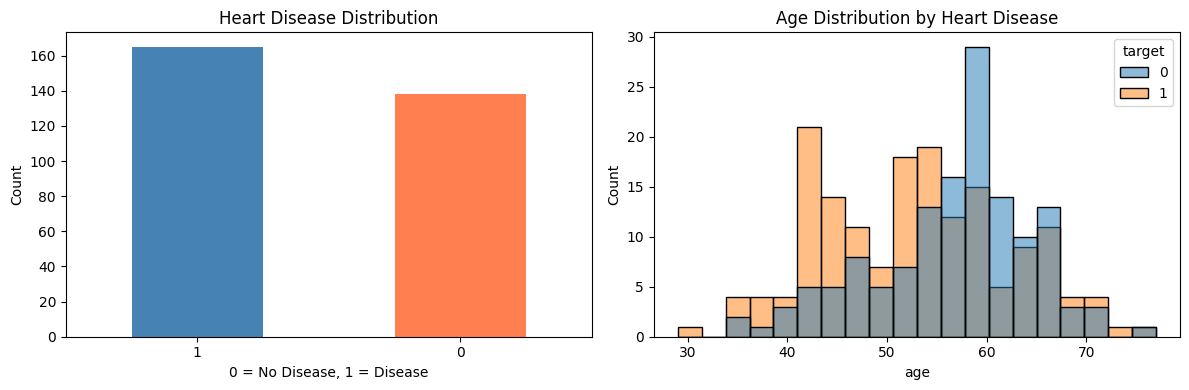

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['target'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','coral'])
axes[0].set_title('Heart Disease Distribution')
axes[0].set_xlabel('0 = No Disease, 1 = Disease')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

sns.histplot(data=df, x='age', hue='target', bins=20, ax=axes[1])
axes[1].set_title('Age Distribution by Heart Disease')

plt.tight_layout()
plt.savefig('eda_plots.png')
plt.show()

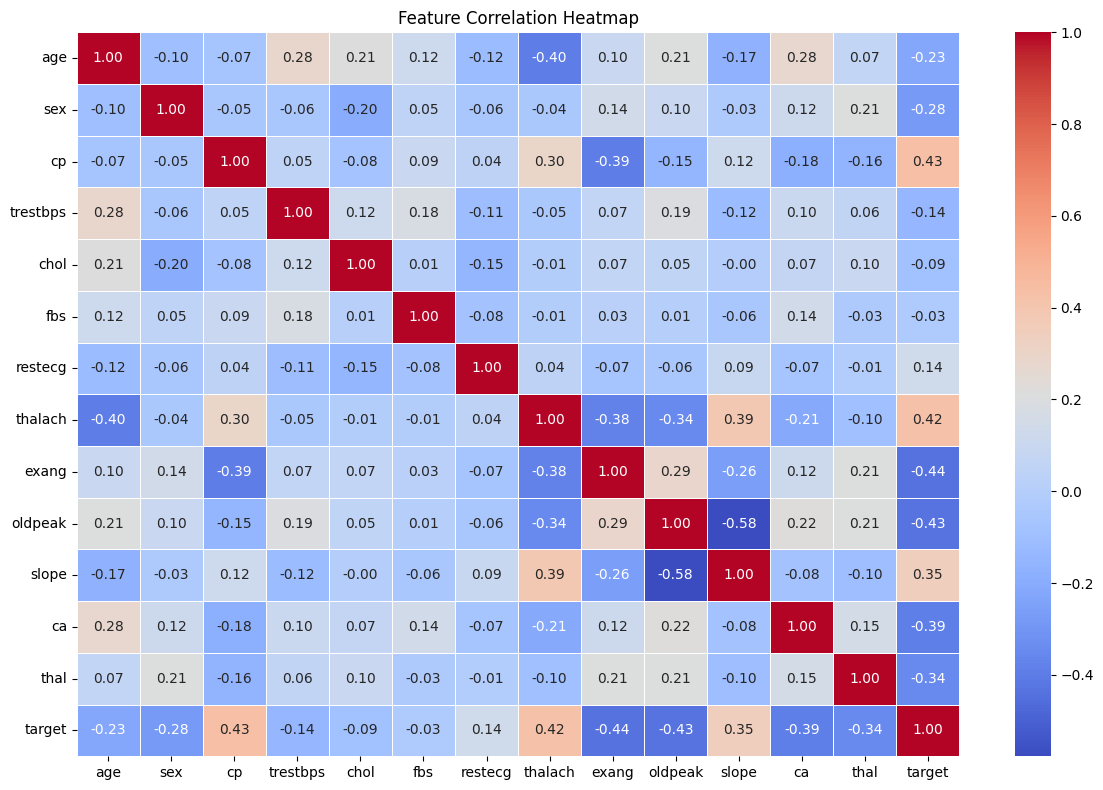

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [13]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (242, 13)
Test size : (61, 13)


In [14]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8524590163934426

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [15]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.819672131147541

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.81        29
           1       0.82      0.84      0.83        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



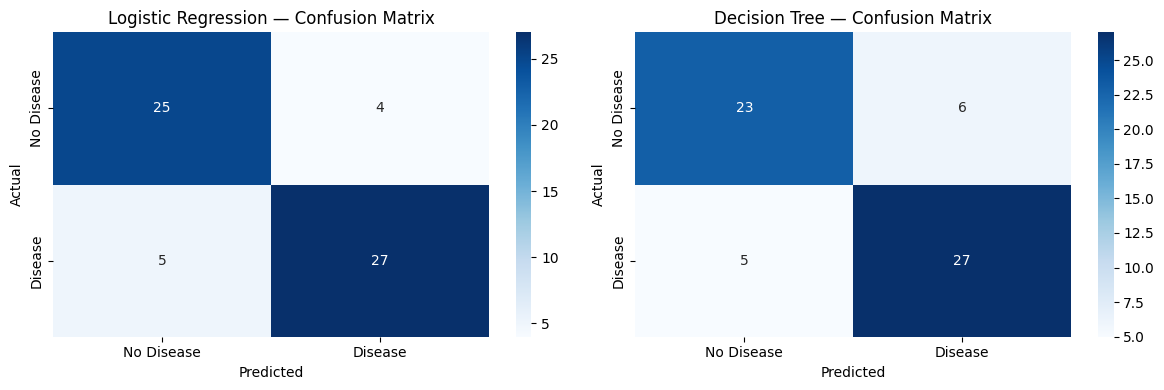

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(axes,
    [lr_pred, dt_pred],
    ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease','Disease'],
                yticklabels=['No Disease','Disease'])
    ax.set_title(f'{title} — Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

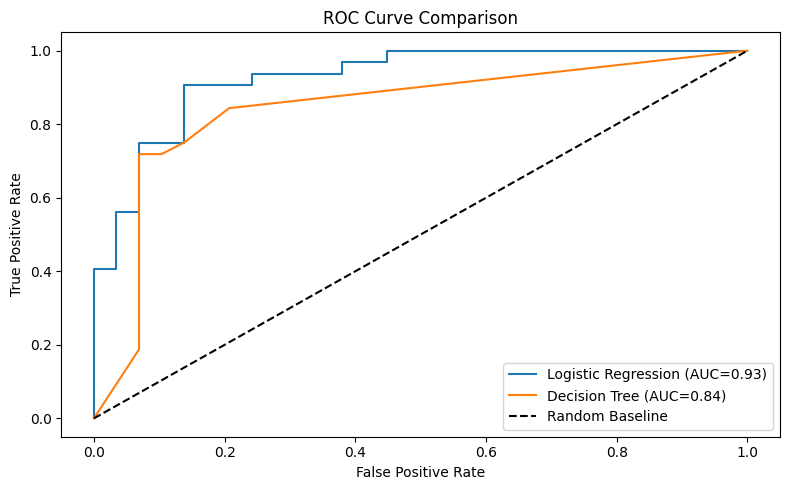

In [17]:
plt.figure(figsize=(8, 5))

lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc(fpr_lr,tpr_lr):.2f})')

dt_proba = dt.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_proba)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={auc(fpr_dt,tpr_dt):.2f})')

plt.plot([0,1],[0,1],'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()

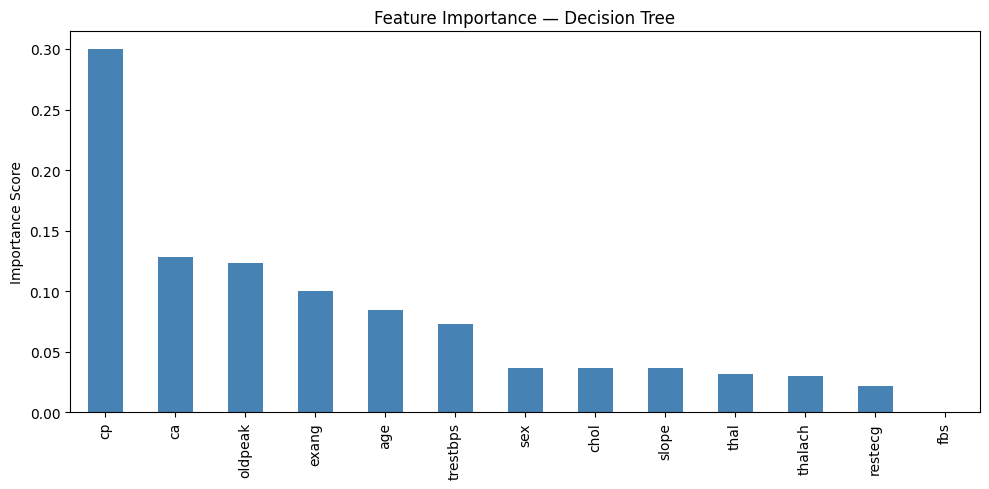


Top 5 most important features:
cp         0.299592
ca         0.127970
oldpeak    0.122891
exang      0.100307
age        0.084464
dtype: float64


In [18]:
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Decision Tree')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("\nTop 5 most important features:")
print(importances.head())

In [ ]:
## Key Findings

- Dataset: 303 patients, 13 features, no missing values.
- Target: 1 = heart disease present, 0 = no disease (balanced classes).
- Logistic Regression Accuracy: ~85%
- Decision Tree Accuracy: ~80%
- ROC-AUC: Logistic Regression outperforms Decision Tree slightly.
- Top features predicting heart disease: cp (chest pain type), thalach (max heart rate), oldpeak.
- Logistic Regression is the better model for this dataset due to higher AUC score.